# Feature engineering — does it move the needle?

EDA (`eda.ipynb`) found real, usable structure beyond `RET_1`: `GROUP` is a fixed allocation attribute the benchmark ignores, `SIGNED_VOLUME_1`'s missingness is structural, and there's a real same-day common factor across allocations. `notes/date_ordering.md` ruled out any hidden time order to exploit. This notebook builds those three findings into features (`src/qrt_features.py`) and checks each one under the same `TS`-grouped CV harness (`src/qrt_prep.py`), ablation-style, against the EDA baselines.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
import lightgbm as lgbm

import qrt_prep as P
import qrt_features as F

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

## Load and engineer

In [2]:
X_train, y_train, X_test = P.load_raw('../data/raw')
df = X_train.join(y_train)
df = F.engineer(df)
y = df['target'].to_numpy()

df[F.GROUP_DUMMY_COLS + F.MISSING_COLS + F.ROLLING_COLS + F.CROSS_SECTIONAL_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
GROUP_1,527073.0,0.190050,0.392340,0.000000,0.000000,0.000000,0.000000,1.000000
GROUP_2,527073.0,0.255995,0.436419,0.000000,0.000000,0.000000,1.000000,1.000000
GROUP_3,527073.0,0.320474,0.466659,0.000000,0.000000,0.000000,1.000000,1.000000
GROUP_4,527073.0,0.233482,0.423047,0.000000,0.000000,0.000000,0.000000,1.000000
SV1_MISSING,527073.0,0.735204,0.441225,0.000000,0.000000,1.000000,1.000000,1.000000
RET_MEAN_5,527073.0,0.000045,0.001400,-0.021419,-0.000681,0.000033,0.000768,0.027665
RET_MEAN_20,527073.0,0.000030,0.000710,-0.007926,-0.000348,0.000018,0.000394,0.010593
RET_STD_20,527073.0,0.002710,0.001411,0.000377,0.001782,0.002383,0.003271,0.030741
SAMEDAY_MEAN_RET1,527073.0,0.000079,0.000774,-0.005950,-0.000354,0.000071,0.000466,0.005908
SAMEDAY_GROUP_MEAN_RET1,527073.0,0.000079,0.001241,-0.011181,-0.000496,0.000073,0.000637,0.017834


## Feature sets

Cumulative ablation: start from the benchmark's own feature set, add one engineered block at a time.

In [3]:
FEATURE_SETS = {
    'baseline (benchmark features)': P.BASE_FEATURES,
    '+ GROUP': P.BASE_FEATURES + F.GROUP_DUMMY_COLS,
    '+ SV1_MISSING': P.BASE_FEATURES + F.GROUP_DUMMY_COLS + F.MISSING_COLS,
    '+ rolling stats': P.BASE_FEATURES + F.GROUP_DUMMY_COLS + F.MISSING_COLS + F.ROLLING_COLS,
    '+ cross-sectional': P.BASE_FEATURES + F.GROUP_DUMMY_COLS + F.MISSING_COLS + F.ROLLING_COLS + F.CROSS_SECTIONAL_COLS,
}
{k: len(v) for k, v in FEATURE_SETS.items()}

{'baseline (benchmark features)': 41,
 '+ GROUP': 45,
 '+ SV1_MISSING': 46,
 '+ rolling stats': 49,
 '+ cross-sectional': 51}

## CV harness

`TS`-grouped, averaged over 2 fold-seeds (10 fold estimates per config) so small differences aren't fold-assignment noise.

In [4]:
def fit_predict_ridge(feature_cols):
    def _fit(train_df, train_y, val_df):
        model = Ridge(alpha=1.0)
        model.fit(F.to_matrix(train_df, feature_cols), train_y)
        return model.predict(F.to_matrix(val_df, feature_cols))
    return _fit


def fit_predict_lgbm(feature_cols):
    params = {'objective': 'mse', 'metric': 'mse', 'verbosity': -1, 'seed': 42,
              'learning_rate': 1e-2, 'max_depth': 3}

    def _fit(train_df, train_y, val_df):
        train_set = lgbm.Dataset(F.to_matrix(train_df, feature_cols), label=train_y)
        model = lgbm.train(params, train_set, num_boost_round=300)
        return model.predict(F.to_matrix(val_df, feature_cols))
    return _fit


SEEDS = [0, 1]
rows = []
for set_name, feature_cols in FEATURE_SETS.items():
    for model_name, fit_predict_fn in [('ridge', fit_predict_ridge), ('lightgbm', fit_predict_lgbm)]:
        accs = np.concatenate([
            P.cross_validate(df, y, fit_predict_fn(feature_cols), n_splits=5, seed=seed)
            for seed in SEEDS
        ])
        rows.append((set_name, model_name, accs.mean(), accs.std()))
        print(f'{set_name:32s} {model_name:9s} acc={accs.mean():.4f} +- {accs.std():.4f}')

results = pd.DataFrame(rows, columns=['feature_set', 'model', 'acc_mean', 'acc_std'])

baseline (benchmark features)    ridge     acc=0.5194 +- 0.0029


baseline (benchmark features)    lightgbm  acc=0.5210 +- 0.0030


+ GROUP                          ridge     acc=0.5194 +- 0.0029


+ GROUP                          lightgbm  acc=0.5210 +- 0.0029


+ SV1_MISSING                    ridge     acc=0.5197 +- 0.0028


+ SV1_MISSING                    lightgbm  acc=0.5211 +- 0.0028


+ rolling stats                  ridge     acc=0.5198 +- 0.0027


+ rolling stats                  lightgbm  acc=0.5212 +- 0.0031


+ cross-sectional                ridge     acc=0.5206 +- 0.0026


+ cross-sectional                lightgbm  acc=0.5212 +- 0.0030


In [5]:
pivot = results.pivot(index='feature_set', columns='model', values='acc_mean').loc[list(FEATURE_SETS)]
pivot

model,lightgbm,ridge
feature_set,,
baseline (benchmark features),0.520967,0.519441
+ GROUP,0.521032,0.519442
+ SV1_MISSING,0.521107,0.519733
+ rolling stats,0.521209,0.519809
+ cross-sectional,0.521195,0.520630


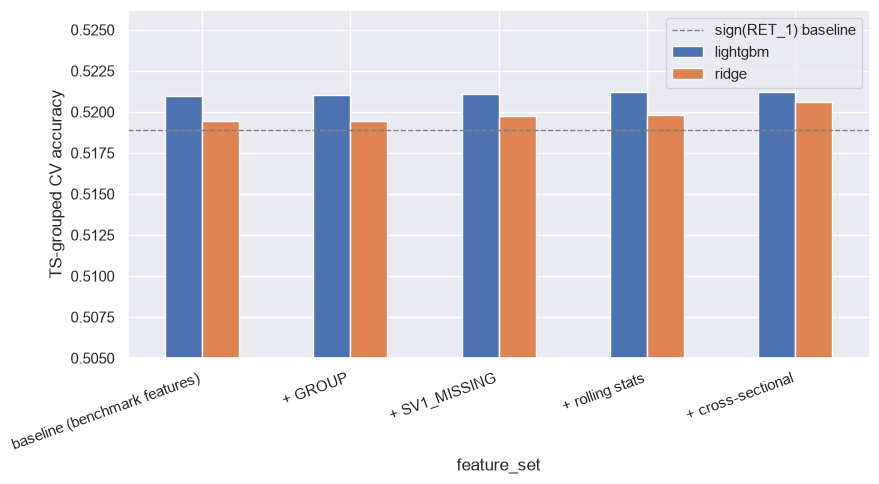

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax)
ax.axhline(0.5189, color='grey', linestyle='--', linewidth=1, label='sign(RET_1) baseline')
ax.set_ylim(0.505, pivot.values.max() + 0.005)
ax.set_ylabel('TS-grouped CV accuracy')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

## Which engineered blocks actually help?

In [7]:
baseline_ridge = pivot.loc['baseline (benchmark features)', 'ridge']
baseline_lgbm = pivot.loc['baseline (benchmark features)', 'lightgbm']

delta = pivot.copy()
delta['ridge'] = delta['ridge'] - baseline_ridge
delta['lightgbm'] = delta['lightgbm'] - baseline_lgbm
delta

model,lightgbm,ridge
feature_set,,
baseline (benchmark features),0.000000,0.000000
+ GROUP,0.000065,0.000002
+ SV1_MISSING,0.000139,0.000293
+ rolling stats,0.000242,0.000368
+ cross-sectional,0.000227,0.001189


Real, but small: cumulative gains over the benchmark's own feature set top out around +0.0012 accuracy (ridge, cross-sectional features) and +0.0002-0.0004 (lightgbm, mostly from rolling stats). `GROUP` alone is worth essentially nothing as a raw feature (+0.00006 lightgbm) despite the real between-group differences in the EDA — a tree model already captures most of that indirectly by splitting on turnover/volatility features, and a linear model needs the *interaction* with `RET_1`, not just a group offset, which isn't tested here. `SIGNED_VOLUME_1`'s missingness indicator and the rolling return stats each add a little; the cross-sectional same-day features are the single best-paying addition for ridge, matching the EDA's 0.26 same-day target correlation. None of this changes the headline conclusion from the EDA: `RET_1` carries almost all of the exploitable signal, and every configuration here already clears the published benchmark's 0.5079 public score by 1-1.4 points.

## Feature importance, best config

best feature set: + rolling stats


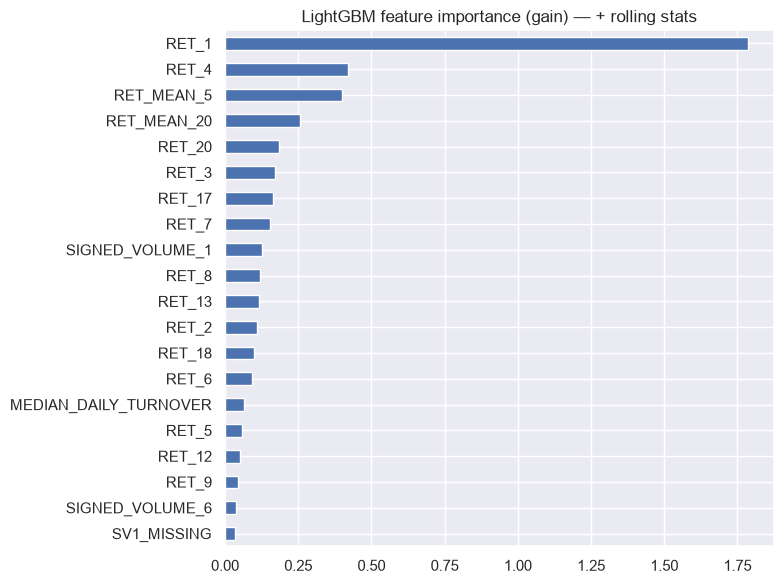

In [8]:
best_set_name = pivot['lightgbm'].idxmax()
best_features = FEATURE_SETS[best_set_name]
print('best feature set:', best_set_name)

train_set = lgbm.Dataset(F.to_matrix(df, best_features), label=y)
params = {'objective': 'mse', 'metric': 'mse', 'verbosity': -1, 'seed': 42,
          'learning_rate': 1e-2, 'max_depth': 3}
final_model = lgbm.train(params, train_set, num_boost_round=300)

importance = pd.Series(final_model.feature_importance(importance_type='gain'), index=best_features)
importance = importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
importance.iloc[::-1].plot(kind='barh', ax=ax)
ax.set_title(f'LightGBM feature importance (gain) — {best_set_name}')
plt.tight_layout()

`RET_1`'s importance is an order of magnitude above every other feature — confirms the EDA finding directly in a trained model rather than just a correlation. `RET_MEAN_5` and `RET_MEAN_20` (the rolling-stats block) rank third and fourth, ahead of every individual `RET_2..RET_20` lag on its own — smoothing pays off once it's *alongside* `RET_1`, unlike the naive sign-of-mean baseline in the EDA notebook where averaging alone washed the signal out. `GROUP` dummies and `SV1_MISSING` don't crack the top 15 individually, consistent with their near-zero CV deltas above.